In [1]:
import pandas as pd

file_path = 'analise_ivcad/df_prop_binario_ivcad.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,REF_CAD,IBGE_REG,IBGE_UF,IBGE_MUN,VL_RENDA_MEDIA_FAM,NC1,NC2,NC3,NC4,...,CH8,CH9,CH10,CH11,CH12,CH13,CH14,classe_renda,y_bin,classe_risco_qualificacao
0,1785304,202511,2,25,2510808,1045.0,0,1,1,0,...,0,0,0,0,0,0,0,2,1,renda formal per capita (CNIS) > ½ SM
1,2588078,202511,2,28,2803708,0.0,0,0,0,1,...,0,0,1,1,1,0,0,0,0,renda formal per capita (CNIS) ≤ ½ SM
2,2516444,202511,2,28,2800308,143.0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,renda formal per capita (CNIS) ≤ ½ SM
3,3197612,202511,2,29,2917607,356.0,0,0,0,0,...,0,1,1,1,1,0,0,1,0,renda formal per capita (CNIS) ≤ ½ SM
4,2956033,202511,2,29,2931350,348.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,renda formal per capita (CNIS) ≤ ½ SM


In [2]:
df.columns

Index(['ID_FAM_ANON', 'REF_CAD', 'IBGE_REG', 'IBGE_UF', 'IBGE_MUN',
       'VL_RENDA_MEDIA_FAM', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
       'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5', 'TQA1',
       'TQA2', 'TQA3', 'TQA4', 'TQA5', 'CH1', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'classe_renda',
       'y_bin', 'classe_risco_qualificacao'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 41 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   ID_FAM_ANON                1000000 non-null  int64  
 1   REF_CAD                    1000000 non-null  int64  
 2   IBGE_REG                   1000000 non-null  int64  
 3   IBGE_UF                    1000000 non-null  int64  
 4   IBGE_MUN                   1000000 non-null  int64  
 5   VL_RENDA_MEDIA_FAM         1000000 non-null  float64
 6   NC1                        1000000 non-null  int64  
 7   NC2                        1000000 non-null  int64  
 8   NC3                        1000000 non-null  int64  
 9   NC4                        1000000 non-null  int64  
 10  NC5                        1000000 non-null  int64  
 11  NC6                        1000000 non-null  int64  
 12  NC7                        1000000 non-null  int64  
 13  DPI1         

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [6]:
df['y_bin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: y_bin
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


## Separação treino e teste

In [7]:
df["ID_FAM_ANON"].is_unique

True

In [8]:
df.columns

Index(['ID_FAM_ANON', 'REF_CAD', 'IBGE_REG', 'IBGE_UF', 'IBGE_MUN',
       'VL_RENDA_MEDIA_FAM', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
       'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5', 'TQA1',
       'TQA2', 'TQA3', 'TQA4', 'TQA5', 'CH1', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'classe_renda',
       'y_bin', 'classe_risco_qualificacao'],
      dtype='object')

In [9]:
colunas_excluir = [
    "classe_renda",
    "y_bin",
    "classe_risco_qualificacao",
    "VL_RENDA_MEDIA_FAM",
    "REF_CAD",
    "ID_FAM_ANON"
]

X = df.drop(columns=colunas_excluir)
y = df["y_bin"]


In [10]:
df.columns

Index(['ID_FAM_ANON', 'REF_CAD', 'IBGE_REG', 'IBGE_UF', 'IBGE_MUN',
       'VL_RENDA_MEDIA_FAM', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
       'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5', 'TQA1',
       'TQA2', 'TQA3', 'TQA4', 'TQA5', 'CH1', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'classe_renda',
       'y_bin', 'classe_risco_qualificacao'],
      dtype='object')

In [11]:
X.columns

Index(['IBGE_REG', 'IBGE_UF', 'IBGE_MUN', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5',
       'NC6', 'NC7', 'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4',
       'DCA5', 'TQA1', 'TQA2', 'TQA3', 'TQA4', 'TQA5', 'CH1', 'CH2', 'CH5',
       'CH6', 'CH7', 'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14'],
      dtype='object')

## Análise de correlação das variáveis

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

# Códigos geográficos — tratados como categóricos ordinais
geo_cols = ['IBGE_REG', 'IBGE_UF', 'IBGE_MUN']

# Indicadores IVCAD — todos booleanos (0/1)
bool_cols = [
    'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
    'DPI1', 'DPI2', 'DPI3',
    'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5',
    'TQA1', 'TQA2', 'TQA3', 'TQA4', 'TQA5',
    'CH1', 'CH2', 'CH5', 'CH6', 'CH7', 'CH8', 'CH9',
    'CH10', 'CH11', 'CH12', 'CH13', 'CH14'
]

# Conjuntos auxiliares para testar tipo rapidamente
# Geográficos são tratados como categóricos no chi2
# Booleanos são tratados como categóricos (chi2) E numéricos (correlação ponto-bisserial)
cat_all = geo_cols + bool_cols   # todas as variáveis discretas/categóricas
num_all = bool_cols              # booleanos também aceitam estatísticas numéricas

set_cat = set(cat_all)
set_num = set(num_all)
set_geo = set(geo_cols)

# Todas as variáveis consideradas
all_vars = cat_all  # geo + bool (sem sobreposição)

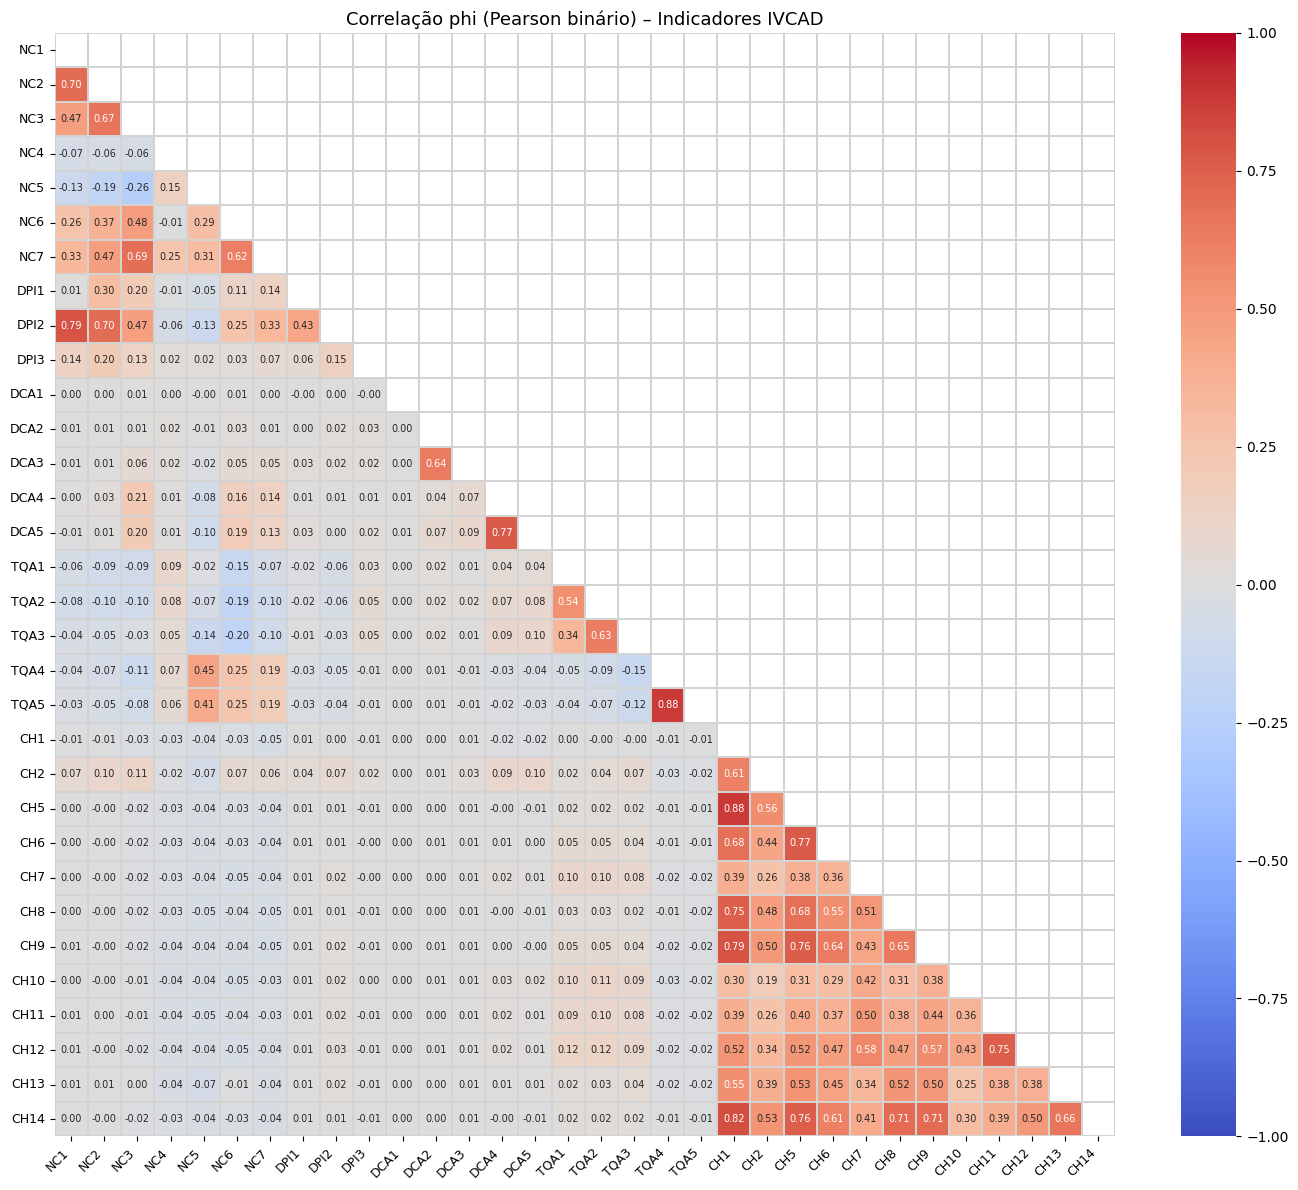

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas os indicadores booleanos IVCAD
df_bool = X[bool_cols]

# Matriz de correlação phi (= Pearson para variáveis binárias)
corr_bool = df_bool.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_bool, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_bool.round(2),
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cmap='coolwarm',
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='lightgrey'
)
plt.title("Correlação phi (Pearson binário) – Indicadores IVCAD", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


In [14]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_bool
        .where(np.triu(np.ones(corr_bool.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar coorelação > 0.80
corr_pairs_sorted[corr_pairs_sorted['corr'].abs() >= 0.80]


,var1,var2,corr
405,TQA4,TQA5,0.883076
431,CH1,CH5,0.879088
440,CH1,CH14,0.823204


In [26]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr
405,TQA4,TQA5,0.883076
431,CH1,CH5,0.879088
440,CH1,CH14,0.823204


In [15]:
X = X.drop(columns=['TQA4', 'CH1'])

In [16]:
X.columns

Index(['IBGE_REG', 'IBGE_UF', 'IBGE_MUN', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5',
       'NC6', 'NC7', 'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4',
       'DCA5', 'TQA1', 'TQA2', 'TQA3', 'TQA5', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14'],
      dtype='object')

In [17]:
X.head()

,IBGE_REG,IBGE_UF,IBGE_MUN,NC1,NC2,NC3,NC4,NC5,NC6,NC7,...,CH5,CH6,CH7,CH8,CH9,CH10,CH11,CH12,CH13,CH14
0,2,25,2510808,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,28,2803708,0,0,0,1,0,0,1,...,0,0,1,0,0,1,1,1,0,0
2,2,28,2800308,0,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,2,29,2917607,0,0,0,0,0,0,0,...,1,1,1,0,1,1,1,1,0,0
4,2,29,2931350,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column    Non-Null Count    Dtype
---  ------    --------------    -----
 0   IBGE_REG  1000000 non-null  int64
 1   IBGE_UF   1000000 non-null  int64
 2   IBGE_MUN  1000000 non-null  int64
 3   NC1       1000000 non-null  int64
 4   NC2       1000000 non-null  int64
 5   NC3       1000000 non-null  int64
 6   NC4       1000000 non-null  int64
 7   NC5       1000000 non-null  int64
 8   NC6       1000000 non-null  int64
 9   NC7       1000000 non-null  int64
 10  DPI1      1000000 non-null  int64
 11  DPI2      1000000 non-null  int64
 12  DPI3      1000000 non-null  int64
 13  DCA1      1000000 non-null  int64
 14  DCA2      1000000 non-null  int64
 15  DCA3      1000000 non-null  int64
 16  DCA4      1000000 non-null  int64
 17  DCA5      1000000 non-null  int64
 18  TQA1      1000000 non-null  int64
 19  TQA2      1000000 non-null  int64
 20  TQA3      1000000 non-nul

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [19]:
X.columns

Index(['IBGE_REG', 'IBGE_UF', 'IBGE_MUN', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5',
       'NC6', 'NC7', 'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4',
       'DCA5', 'TQA1', 'TQA2', 'TQA3', 'TQA5', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14'],
      dtype='object')

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

# Códigos geográficos — categóricos nominais
geo_cols = ['IBGE_REG', 'IBGE_UF', 'IBGE_MUN']

# Indicadores IVCAD — booleanos (0/1)
bool_cols = [
    'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
    'DPI1', 'DPI2', 'DPI3',
    'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5',
    'TQA1', 'TQA2', 'TQA3', 'TQA4', 'TQA5',
    'CH1', 'CH2', 'CH5', 'CH6', 'CH7', 'CH8', 'CH9',
    'CH10', 'CH11', 'CH12', 'CH13', 'CH14'
]

# Conjuntos auxiliares para testar tipo rapidamente
# Geográficos: categóricos nominais (chi2 / Cramér's V)
# Booleanos: categóricos binários (chi2 / phi = Pearson binário)
cat_all = geo_cols + bool_cols   # todas as discretas
num_all = bool_cols              # booleanos aceitam estatísticas numéricas também

set_cat = set(cat_all)
set_num = set(num_all)
set_geo = set(geo_cols)
set_bool = set(bool_cols)

# Todas as variáveis consideradas
all_vars = geo_cols + bool_cols

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Filtrar apenas colunas que existem em X
bool_cols_eff = [c for c in bool_cols if c in X.columns]
geo_ohe_cols  = [c for c in ['IBGE_REG', 'IBGE_UF'] if c in X.columns]
geo_ord_cols  = [c for c in ['IBGE_MUN'] if c in X.columns]

print(f"geo_ohe : {geo_ohe_cols}")
print(f"geo_ord : {geo_ord_cols}")
print(f"bool    : {len(bool_cols_eff)} colunas → {bool_cols_eff}")

# Pipeline para geo com OHE
pipeline_geo_ohe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Preprocessor final
preprocessor = ColumnTransformer([
    ("geo_ohe", pipeline_geo_ohe, geo_ohe_cols),  # OHE para REG e UF
    ("geo_ord", "passthrough",    geo_ord_cols),   # inteiro direto para MUN
    ("bool",    "passthrough",    bool_cols_eff),  # booleanos sem transformação
])


geo_ohe : ['IBGE_REG', 'IBGE_UF']
geo_ord : ['IBGE_MUN']
bool    : 30 colunas → ['NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7', 'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5', 'TQA1', 'TQA2', 'TQA3', 'TQA5', 'CH2', 'CH5', 'CH6', 'CH7', 'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14']


## Separando em treino e teste

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [24]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('geo_ohe',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['IBGE_REG', 'IBGE_UF']),
                                ('geo_ord', 'passthrough', ['IBGE_MUN']),
                                ('bool', 'passthrough',
                                 ['NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6',
                                  'NC7', 'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2',
                                  'DCA3', 'DCA4', 'DCA5', 'TQA1', 'TQA2',
                                  'TQA3', 'TQA5', 'CH2', 'CH5', 'CH6', 'CH7',
                                  'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13',
                                  'CH14'])])

In [26]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,geo_ohe__IBGE_REG_1,geo_ohe__IBGE_REG_2,geo_ohe__IBGE_REG_3,geo_ohe__IBGE_REG_4,geo_ohe__IBGE_REG_5,geo_ohe__IBGE_UF_11,geo_ohe__IBGE_UF_12,geo_ohe__IBGE_UF_13,geo_ohe__IBGE_UF_14,geo_ohe__IBGE_UF_15,...,bool__CH5,bool__CH6,bool__CH7,bool__CH8,bool__CH9,bool__CH10,bool__CH11,bool__CH12,bool__CH13,bool__CH14
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Comparando diversos modelos

In [27]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ------------------------------------------------------------
# 0) CONFIG DE TRIAGEM
# ------------------------------------------------------------
SEED = 42
THRESHOLD_TRIAGEM = 0.80  # ajuste depois conforme capacidade operacional
POS_LABEL = 1             # 1 = acima de 1/2 SM (potencialmente não elegível)


# ------------------------------------------------------------
# 1) MODELOS (ajustados para BINÁRIO)
# ------------------------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        random_state=SEED
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"  # ajuda quando há desbalanceamento
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=1200,          # mais árvores + taxa menor costuma ajudar
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
        # (opcional) scale_pos_weight pode ser ajustado se a classe 1 for rara
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False
        # (opcional) class_weights=[w0, w1] se necessário
    ),
}


# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (com métricas para TRIAGEM)
# ------------------------------------------------------------
pipes = {}
results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    # Predição padrão (threshold 0.5)
    y_pred_05 = pipe.predict(X_test).ravel()

    # Probabilidades (para AUC/PR-AUC e para threshold de triagem)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    # Predição para TRIAGEM (threshold configurável)
    if y_proba is not None:
        y_pred_t = (y_proba >= THRESHOLD_TRIAGEM).astype(int)
    else:
        y_pred_t = y_pred_05  # fallback

    # -------------------------
    # Métricas: padrão 0.5
    # -------------------------
    acc_05 = accuracy_score(y_test, y_pred_05)
    balacc_05 = balanced_accuracy_score(y_test, y_pred_05)

    prec_05 = precision_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    rec_05  = recall_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    f1_05   = f1_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)

    tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1]).ravel()

    # -------------------------
    # Métricas: TRIAGEM (threshold = THRESHOLD_TRIAGEM)
    # -------------------------
    acc_t = accuracy_score(y_test, y_pred_t)
    balacc_t = balanced_accuracy_score(y_test, y_pred_t)

    prec_t = precision_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    f1_t   = f1_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)

    tnt, fpt, fnt, tpt = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()

    # -------------------------
    # AUC / PR-AUC (se houver proba)
    # -------------------------
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)  # PR-AUC (muito útil p/ triagem)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # "Taxa de convocação" no teste (volume relativo gerado pela regra)
    convoc_rate = float(np.mean(y_pred_t == 1))

    results.append({
        "modelo": name,

        # Ranking mais aderente ao objetivo de triagem
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,

        # Métricas com threshold padrão
        "acc@0.50": acc_05,
        "bal_acc@0.50": balacc_05,
        "prec_pos@0.50": prec_05,
        "rec_pos@0.50": rec_05,
        "f1_pos@0.50": f1_05,
        "tp@0.50": tp05, "fp@0.50": fp05, "fn@0.50": fn05, "tn@0.50": tn05,

        # Métricas para a regra operacional de triagem
        f"acc@{THRESHOLD_TRIAGEM:.2f}": acc_t,
        f"bal_acc@{THRESHOLD_TRIAGEM:.2f}": balacc_t,
        f"prec_pos@{THRESHOLD_TRIAGEM:.2f}": prec_t,
        f"rec_pos@{THRESHOLD_TRIAGEM:.2f}": rec_t,
        f"f1_pos@{THRESHOLD_TRIAGEM:.2f}": f1_t,
        f"tp@{THRESHOLD_TRIAGEM:.2f}": tpt, f"fp@{THRESHOLD_TRIAGEM:.2f}": fpt,
        f"fn@{THRESHOLD_TRIAGEM:.2f}": fnt, f"tn@{THRESHOLD_TRIAGEM:.2f}": tnt,

        # volume gerado
        f"taxa_convocacao@{THRESHOLD_TRIAGEM:.2f}": convoc_rate,
    })


# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = (
    pd.DataFrame(results)
      .sort_values(["pr_auc", "roc_auc"], ascending=False)
      .reset_index(drop=True)
)

df_results



Treinando modelo: LogisticRegression

Treinando modelo: RandomForest

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,pr_auc,roc_auc,acc@0.50,bal_acc@0.50,prec_pos@0.50,rec_pos@0.50,f1_pos@0.50,tp@0.50,fp@0.50,...,acc@0.80,bal_acc@0.80,prec_pos@0.80,rec_pos@0.80,f1_pos@0.80,tp@0.80,fp@0.80,fn@0.80,tn@0.80,taxa_convocacao@0.80
0,XGBoost,0.773936,0.784929,0.710065,0.709597,0.701354,0.744912,0.722477,75479,32140,...,0.586340,0.591319,0.869838,0.215799,0.345806,21866,3272,79460,95402,0.125690
1,CatBoost,0.773568,0.784505,0.709445,0.708993,0.701245,0.743067,0.721551,75292,32077,...,0.584740,0.589745,0.869142,0.212315,0.341265,21513,3239,79813,95435,0.123760
2,HistGradientBoosting,0.772276,0.783410,0.708365,0.707903,0.699967,0.742722,0.720711,75257,32258,...,0.583580,0.588608,0.869683,0.209443,0.337586,21222,3180,80104,95494,0.122010
3,RandomForest,0.706672,0.726925,0.668395,0.667982,0.664070,0.699139,0.681154,70841,35836,...,0.605805,0.609522,0.754223,0.329205,0.458349,33357,10870,67969,87804,0.221135
4,LogisticRegression,0.699201,0.723778,0.665605,0.665354,0.665266,0.684247,0.674623,69332,34885,...,0.515150,0.521325,0.814922,0.055622,0.104137,5636,1280,95690,97394,0.034580


In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Modelos que você quer comparar
modelos_alvo = ["XGBoost", "HistGradientBoosting", "CatBoost"]

POS_LABEL = 1                  # 1 = acima de 1/2 SM
THRESHOLDS = [0.50, 0.80]       # padrão e triagem

rows = []

for nome in modelos_alvo:
    pipe = pipes[nome]

    # Probabilidades para usar thresholds
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    for thr in THRESHOLDS:
        if y_proba is None:
            # fallback: usa predict padrão (equivalente a 0.5)
            if thr != 0.50:
                continue
            y_pred = pipe.predict(X_test).ravel()
        else:
            y_pred = (y_proba >= thr).astype(int)

        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # guarda resumo (inclui taxa de convocação)
        rows.append({
            "modelo": nome,
            "threshold": thr,
            "precision_pos": rep["1"]["precision"],
            "recall_pos": rep["1"]["recall"],
            "f1_pos": rep["1"]["f1-score"],
            "support_pos": rep["1"]["support"],
            "precision_neg": rep["0"]["precision"],
            "recall_neg": rep["0"]["recall"],
            "f1_neg": rep["0"]["f1-score"],
            "accuracy": rep["accuracy"],
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "taxa_convocacao": float((y_pred == 1).mean())
        })

df_thr = pd.DataFrame(rows).sort_values(["threshold", "f1_pos", "recall_pos"], ascending=False)

print("=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===")
display(df_thr)

# Se quiser uma tabela “apenas triagem” (thr=0.80), já pronta:
df_triagem = (
    df_thr[df_thr["threshold"] == 0.80]
    .sort_values(["precision_pos", "recall_pos"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== Tabela de triagem (threshold=0.80) ===")
display(df_triagem)



=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
1,XGBoost,0.8,0.869838,0.215799,0.345806,101326.0,0.545585,0.966840,0.697546,0.586340,21866,3272,79460,95402,0.125690
5,CatBoost,0.8,0.869142,0.212315,0.341265,101326.0,0.544571,0.967175,0.696804,0.584740,21513,3239,79813,95435,0.123760
3,HistGradientBoosting,0.8,0.869683,0.209443,0.337586,101326.0,0.543822,0.967773,0.696345,0.583580,21222,3180,80104,95494,0.122010
0,XGBoost,0.5,0.701354,0.744912,0.722477,101326.0,0.720213,0.674281,0.696491,0.710065,75479,32140,25847,66534,0.538095
4,CatBoost,0.5,0.701245,0.743067,0.721551,101326.0,0.718949,0.674919,0.696239,0.709445,75292,32077,26034,66597,0.536845
2,HistGradientBoosting,0.5,0.699967,0.742722,0.720711,101326.0,0.718127,0.673085,0.694877,0.708365,75257,32258,26069,66416,0.537575



=== Tabela de triagem (threshold=0.80) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
0,XGBoost,0.8,0.869838,0.215799,0.345806,101326.0,0.545585,0.966840,0.697546,0.58634,21866,3272,79460,95402,0.12569
1,HistGradientBoosting,0.8,0.869683,0.209443,0.337586,101326.0,0.543822,0.967773,0.696345,0.58358,21222,3180,80104,95494,0.12201
2,CatBoost,0.8,0.869142,0.212315,0.341265,101326.0,0.544571,0.967175,0.696804,0.58474,21513,3239,79813,95435,0.12376


In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

pipe = pipes["XGBoost"]
y_proba = pipe.predict_proba(X_test)[:, 1]

THRESHOLDS_EXTRA = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

rows = []
for thr in THRESHOLDS_EXTRA:
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    rows.append({
        "threshold":        thr,
        "precision_pos":    round(rep["1"]["precision"], 4),
        "recall_pos":       round(rep["1"]["recall"], 4),
        "f1_pos":           round(rep["1"]["f1-score"], 4),
        "precision_neg":    round(rep["0"]["precision"], 4),
        "recall_neg":       round(rep["0"]["recall"], 4),
        "accuracy":         round(rep["accuracy"], 4),
        "tp":               int(tp),
        "fp":               int(fp),   # famílias elegíveis convocadas erroneamente
        "fn":               int(fn),
        "tn":               int(tn),
        "taxa_convocacao":  round(float((y_pred == 1).mean()), 4),
        "erro_convocacao":  round(fp / max(tp + fp, 1), 4),  # % de erros entre convocados
    })

df_thr_xgb = pd.DataFrame(rows)

print("=== XGBoost — impacto do threshold na qualidade da triagem ===\n")
display(df_thr_xgb)

# Destaca o ponto de menor erro de convocação com recall mínimo aceitável
RECALL_MIN = 0.10  # ajuste conforme necessidade operacional
df_filtrado = df_thr_xgb[df_thr_xgb["recall_pos"] >= RECALL_MIN]
melhor = df_filtrado.loc[df_filtrado["erro_convocacao"].idxmin()]
print(f"\nMelhor threshold (recall ≥ {RECALL_MIN}, menor erro de convocação):")
print(melhor.to_string())

=== XGBoost — impacto do threshold na qualidade da triagem ===



,threshold,precision_pos,recall_pos,f1_pos,precision_neg,recall_neg,accuracy,tp,fp,fn,tn,taxa_convocacao,erro_convocacao
0,0.50,0.7014,0.7449,0.7225,0.7202,0.6743,0.7101,75479,32140,25847,66534,0.5381,0.2986
1,0.60,0.7484,0.6104,0.6724,0.6636,0.7893,0.6987,61847,20787,39479,77887,0.4132,0.2516
2,0.70,0.8055,0.4132,0.5462,0.5983,0.8975,0.6522,41872,10113,59454,88561,0.2599,0.1945
3,0.75,0.8431,0.2997,0.4422,0.5673,0.9427,0.6169,30363,5651,70963,93023,0.1801,0.1569
4,0.80,0.8698,0.2158,0.3458,0.5456,0.9668,0.5863,21866,3272,79460,95402,0.1257,0.1302
5,0.85,0.8895,0.1482,0.2541,0.5287,0.9811,0.5591,15020,1865,86306,96809,0.0844,0.1105
6,0.90,0.9212,0.0504,0.0956,0.5052,0.9956,0.5167,5110,437,96216,98237,0.0277,0.0788
7,0.95,0.9455,0.0015,0.0031,0.4937,0.9999,0.4941,156,9,101170,98665,0.0008,0.0545



Melhor threshold (recall ≥ 0.1, menor erro de convocação):
threshold              0.8500
precision_pos          0.8895
recall_pos             0.1482
f1_pos                 0.2541
precision_neg          0.5287
recall_neg             0.9811
accuracy               0.5591
tp                 15020.0000
fp                  1865.0000
fn                 86306.0000
tn                 96809.0000
taxa_convocacao        0.0844
erro_convocacao        0.1105


In [32]:
# Threshold operacional definido
THRESHOLD_FINAL = 0.80
MODELO_FINAL    = "XGBoost"

pipe_final = pipes[MODELO_FINAL]
y_proba_final = pipe_final.predict_proba(X_test)[:, 1]
y_pred_final  = (y_proba_final >= THRESHOLD_FINAL).astype(int)

# Resumo da decisão
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"Modelo           : {MODELO_FINAL}")
print(f"Threshold        : {THRESHOLD_FINAL}")
print(f"Famílias convocadas (tp+fp) : {tp+fp:>8,}  ({(tp+fp)/len(y_test)*100:.1f}% do teste)")
print(f"  → Corretas (tp)           : {tp:>8,}  ({tp/(tp+fp)*100:.1f}% das convocadas)")
print(f"  → Erros    (fp)           : {fp:>8,}  ({fp/(tp+fp)*100:.1f}% das convocadas)")
print(f"Famílias não convocadas     : {tn+fn:>8,}")
print(f"  → Elegíveis poupadas (tn) : {tn:>8,}")
print(f"  → Classe 1 não capturadas : {fn:>8,}")

Modelo           : XGBoost
Threshold        : 0.8
Famílias convocadas (tp+fp) :   25,138  (12.6% do teste)
  → Corretas (tp)           :   21,866  (87.0% das convocadas)
  → Erros    (fp)           :    3,272  (13.0% das convocadas)
Famílias não convocadas     :  174,862
  → Elegíveis poupadas (tn) :   95,402
  → Classe 1 não capturadas :   79,460


# Pipeline processamento + Modelo (XGBoost)

In [33]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from xgboost import XGBClassifier

class XGBoostComThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_pos=THRESHOLD_FINAL): 
        self.threshold_pos = threshold_pos
        self.model = XGBClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,   
            n_jobs=-1
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_"])
        return self.model.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, attributes=["classes_"])
        proba_pos = self.model.predict_proba(X)[:, 1]
        return (proba_pos >= self.threshold_pos).astype(int)


# Instancia e treina com o preprocessor já definido
pipe_final = Pipeline([
    ("preprocess", preprocessor),
    ("model",      XGBoostComThreshold(threshold_pos=THRESHOLD_FINAL))
])

pipe_final.fit(X_train, y_train)

# Validação rápida
y_pred_final  = pipe_final.predict(X_test)
y_proba_final = pipe_final.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"Modelo           : XGBoostComThreshold")
print(f"Threshold        : {THRESHOLD_FINAL}")
print(f"Famílias convocadas (tp+fp) : {tp+fp:>8,}  ({(tp+fp)/len(y_test)*100:.1f}% do teste)")
print(f"  → Corretas (tp)           : {tp:>8,}  ({tp/(tp+fp)*100:.1f}% das convocadas)")
print(f"  → Erros    (fp)           : {fp:>8,}  ({fp/(tp+fp)*100:.1f}% das convocadas)")
print(f"Famílias não convocadas     : {tn+fn:>8,}")
print(f"  → Elegíveis poupadas (tn) : {tn:>8,}")
print(f"  → Classe 1 não capturadas : {fn:>8,}")



Modelo           : XGBoostComThreshold
Threshold        : 0.8
Famílias convocadas (tp+fp) :   25,138  (12.6% do teste)
  → Corretas (tp)           :   21,866  (87.0% das convocadas)
  → Erros    (fp)           :    3,272  (13.0% das convocadas)
Famílias não convocadas     :  174,862
  → Elegíveis poupadas (tn) :   95,402
  → Classe 1 não capturadas :   79,460


In [34]:
from sklearn import set_config

set_config(display='diagram')

pipe_final


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('geo_ohe',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['IBGE_REG', 'IBGE_UF']),
                                                 ('geo_ord', 'passthrough',
                                                  ['IBGE_MUN']),
                                                 ('bool', 'passthrough',
                                                  ['NC1', 'NC2', 'NC3', 'NC4',
                                                   'NC5', 'NC6', 'NC7', 'DPI1',
                                                   'DPI2', 'DPI3', 'DCA1',
                                                   'DCA2', 'DCA3', 'DCA4',
                                                   'DCA5', 'TQA1', 'TQA2',
                                                   'TQA3', 'TQA5', 'CH2', 'CH5',
                                                   'CH6', 'CH7', 'CH8', 'CH9',
                                                   'CH10', 'CH11', 'CH12',
                                                   'CH13', 'CH14'])])),
                ('model', XGBoostComThreshold())])

## Avaliação completa do Modelo

=== Avaliação no threshold = 0.80 ===
Acurácia            : 0.5863
Precisão (classe 1) : 0.8698
Revocação (classe 1): 0.2158
F1 (classe 1)       : 0.3458
Taxa de convocação  : 0.1257

Matriz de confusão (valores absolutos):
               Pred ≤ 1/2 SM  Pred > 1/2 SM
Real ≤ 1/2 SM          95402           3272
Real > 1/2 SM          79460          21866


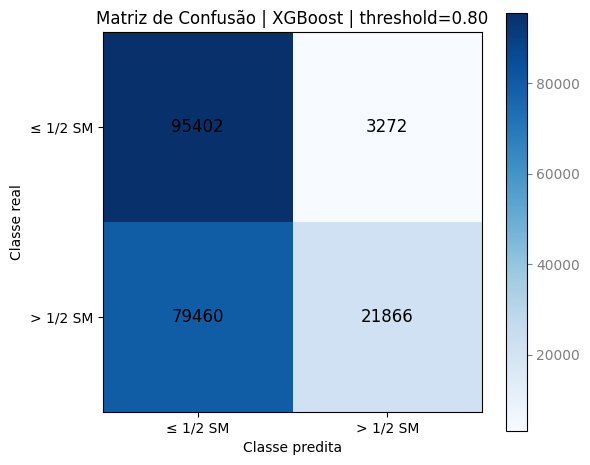

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
THRESHOLD = THRESHOLD_FINAL  # 0.80 definido anteriormente
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"

# ------------------------------------------------------------
# 1) PREDIÇÕES NO THRESHOLD DEFINIDO
# ------------------------------------------------------------
proba_pos = pipe_final.predict_proba(X_test)[:, 1]
y_pred    = (proba_pos >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# 2) MÉTRICAS NUMÉRICAS
# ------------------------------------------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"=== Avaliação no threshold = {THRESHOLD:.2f} ===")
print(f"Acurácia            : {acc:.4f}")
print(f"Precisão (classe 1) : {prec:.4f}")
print(f"Revocação (classe 1): {rec:.4f}")
print(f"F1 (classe 1)       : {f1:.4f}")
print(f"Taxa de convocação  : {(y_pred == 1).mean():.4f}")
print("\nMatriz de confusão (valores absolutos):")
print(pd.DataFrame(
    cm,
    index=["Real ≤ 1/2 SM",  "Real > 1/2 SM"],
    columns=["Pred ≤ 1/2 SM", "Pred > 1/2 SM"]
))

# ------------------------------------------------------------
# 3) PLOT DA MATRIZ DE CONFUSÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title(f"Matriz de Confusão | XGBoost | threshold={THRESHOLD:.2f}")
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["≤ 1/2 SM", "> 1/2 SM"])
ax.set_yticklabels(["≤ 1/2 SM", "> 1/2 SM"])

for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, int(val), ha="center", va="center", fontsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(color=CINZA)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=CINZA)
plt.tight_layout()
plt.show()



ROC-AUC: 0.7849


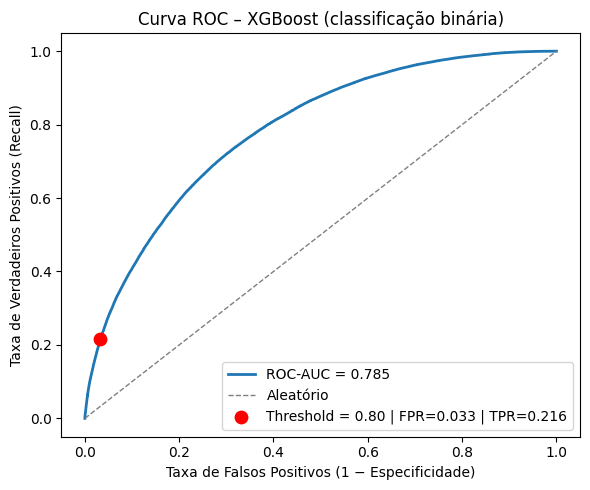

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipe_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA ROC E AUC
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, proba_pos)
roc_auc = roc_auc_score(y_test, proba_pos)
print(f"ROC-AUC: {roc_auc:.4f}")

# Marca o ponto correspondente ao threshold escolhido
idx = np.argmin(np.abs(thresholds - THRESHOLD_FINAL))

# ------------------------------------------------------------
# 3) PLOT DA CURVA ROC
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1, label="Aleatório")

# Ponto do threshold operacional
ax.scatter(
    fpr[idx], tpr[idx],
    color="red", zorder=5, s=80,
    label=f"Threshold = {THRESHOLD_FINAL:.2f} | FPR={fpr[idx]:.3f} | TPR={tpr[idx]:.3f}"
)

ax.set_title("Curva ROC – XGBoost (classificação binária)")
ax.set_xlabel("Taxa de Falsos Positivos (1 − Especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
ax.legend(loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()


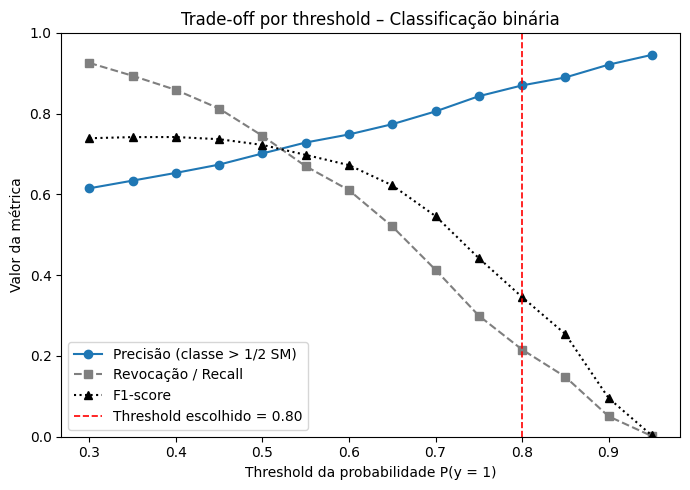

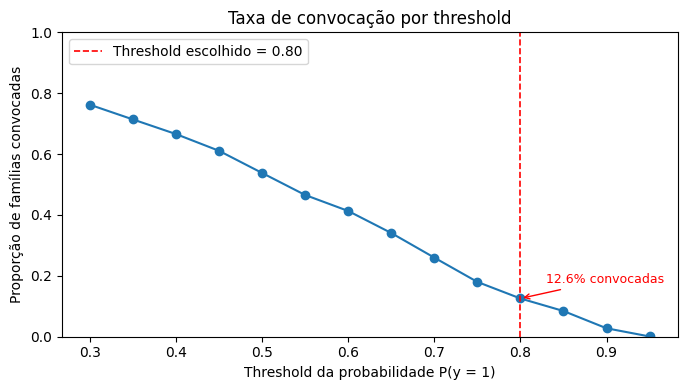

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
PRETO = "#000000"
VERM  = "red"

THRESHOLDS = np.arange(0.30, 0.96, 0.05)

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipe_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DAS MÉTRICAS POR THRESHOLD
# ------------------------------------------------------------
precisoes       = []
revocacoes      = []
f1_scores       = []
taxa_convocacao = []

for t in THRESHOLDS:
    y_pred = (proba_pos >= t).astype(int)
    precisoes.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    revocacoes.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, pos_label=1, zero_division=0))
    taxa_convocacao.append((y_pred == 1).mean())

# Índice do threshold operacional na lista
idx_thr = np.argmin(np.abs(THRESHOLDS - THRESHOLD_FINAL))

# ------------------------------------------------------------
# 3) PLOT DO TRADE-OFF (PRECISÃO, RECALL, F1)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(THRESHOLDS, precisoes,  marker="o", color=AZUL,  label="Precisão (classe > 1/2 SM)")
ax.plot(THRESHOLDS, revocacoes, marker="s", color=CINZA, linestyle="--", label="Revocação / Recall")
ax.plot(THRESHOLDS, f1_scores,  marker="^", color=PRETO, linestyle=":",  label="F1-score")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

ax.set_title("Trade-off por threshold – Classificação binária")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Valor da métrica")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) PLOT DA TAXA DE CONVOCAÇÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(THRESHOLDS, taxa_convocacao, marker="o", color=AZUL)

# Linha vertical + anotação no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")
ax.annotate(
    f"{taxa_convocacao[idx_thr]:.1%} convocadas",
    xy=(THRESHOLD_FINAL, taxa_convocacao[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_convocacao[idx_thr] + 0.05),
    arrowprops=dict(arrowstyle="->", color=VERM),
    color=VERM, fontsize=9
)

ax.set_title("Taxa de convocação por threshold")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Proporção de famílias convocadas")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


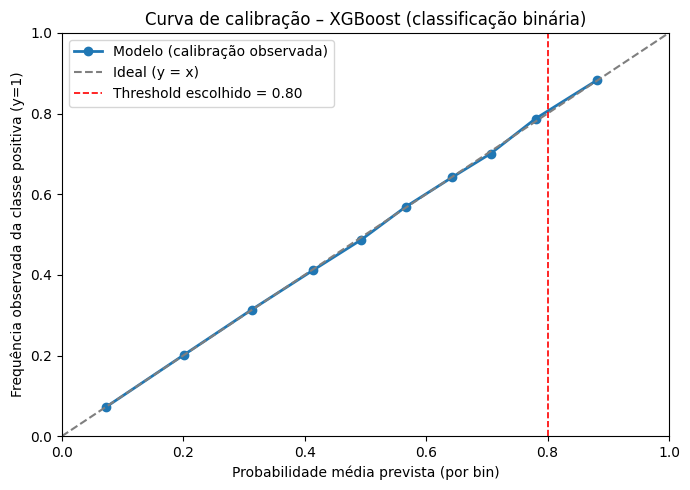

,bin,prob_media_prevista,freq_observada,dif_observada_menos_prevista
0,1,0.0725,0.0721,-0.0004
1,2,0.2007,0.2013,0.0006
2,3,0.3131,0.3141,0.0010
3,4,0.4142,0.4118,-0.0024
4,5,0.4932,0.4871,-0.0061
5,6,0.5661,0.5684,0.0023
6,7,0.6429,0.6420,-0.0010
7,8,0.7061,0.7005,-0.0056
8,9,0.7802,0.7872,0.0070
9,10,0.8808,0.8820,0.0012


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import calibration_curve

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
VERM  = "red"
N_BINS = 10

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipe_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
frac_pos, mean_pred = calibration_curve(
    y_test,
    proba_pos,
    n_bins=N_BINS,
    strategy="quantile"
)

# ------------------------------------------------------------
# 3) PLOT DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mean_pred, frac_pos, marker="o", color=AZUL, linewidth=2,
        label="Modelo (calibração observada)")
ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1.5,
        label="Ideal (y = x)")

# Marca o threshold operacional no eixo X
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

ax.set_title("Curva de calibração – XGBoost (classificação binária)")
ax.set_xlabel("Probabilidade média prevista (por bin)")
ax.set_ylabel("Frequência observada da classe positiva (y=1)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) TABELA RESUMO DOS BINS
# ------------------------------------------------------------
df_calib = pd.DataFrame({
    "bin":                            np.arange(1, len(mean_pred) + 1),
    "prob_media_prevista":            mean_pred.round(4),
    "freq_observada":                 frac_pos.round(4),
    "dif_observada_menos_prevista":   (frac_pos - mean_pred).round(4)
})

display(df_calib)


## Análise da importância das variáveis

Nº features (X.columns)        : 33
Nº features (importances_mean) : 33


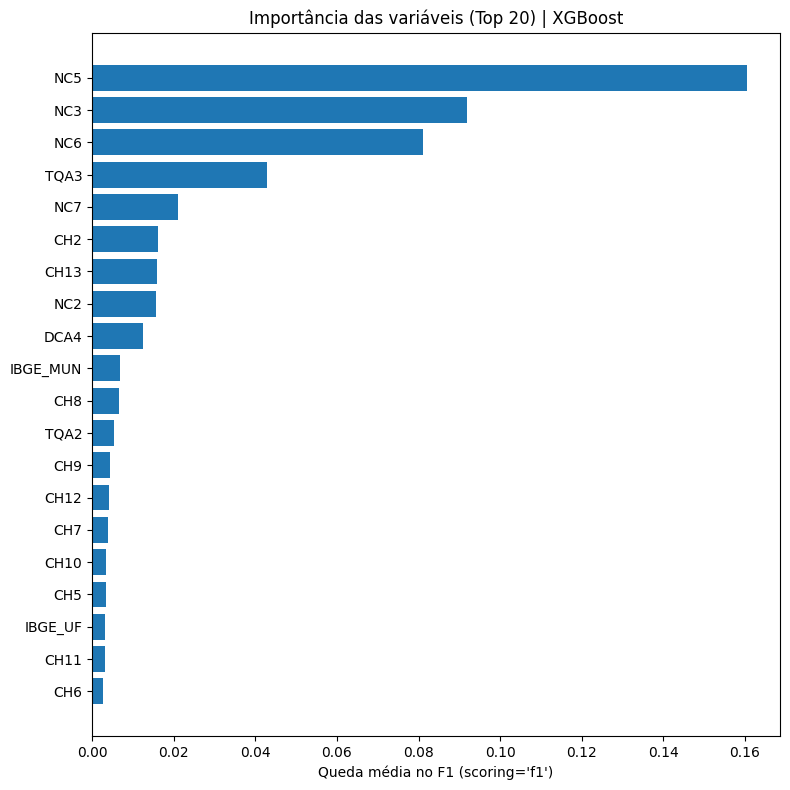

,feature,importance
7,NC5,0.160549
5,NC3,0.091884
8,NC6,0.081059
20,TQA3,0.042935
9,NC7,0.021074
22,CH2,0.016156
31,CH13,0.015896
4,NC2,0.015596
16,DCA4,0.012486
2,IBGE_MUN,0.006770


In [42]:
from sklearn.inspection import permutation_importance
import pandas as pd

def plot_importancia(pipe, X, y, top_n=20, titulo="XGBoost"):
    # Nomes das features de entrada (antes do preprocessor)
    feat_names = list(X.columns)

    r = permutation_importance(
        pipe, X, y,
        n_repeats=5,
        random_state=SEED,
        scoring="f1"
    )

    print(f"Nº features (X.columns)        : {len(feat_names)}")
    print(f"Nº features (importances_mean) : {len(r.importances_mean)}")

    imp = (
        pd.DataFrame({
            "feature":    feat_names,
            "importance": r.importances_mean
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    fig, ax = plt.subplots(figsize=(8, top_n * 0.4))
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=AZUL)
    ax.set_title(f"Importância das variáveis (Top {top_n}) | {titulo}")
    ax.set_xlabel("Queda média no F1 (scoring='f1')")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    return imp

# Execução
imp_df = plot_importancia(pipe_final, X_test, y_test, top_n=20)
display(imp_df)

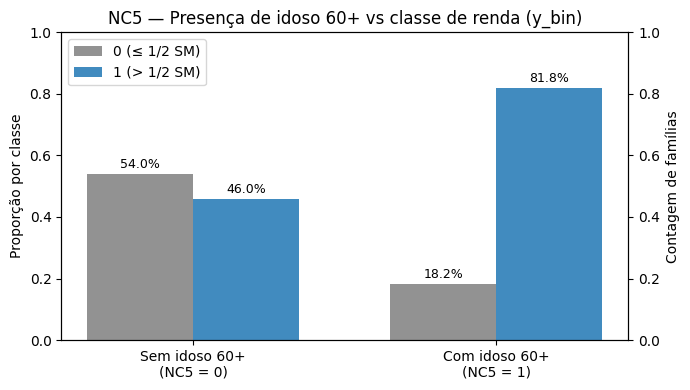

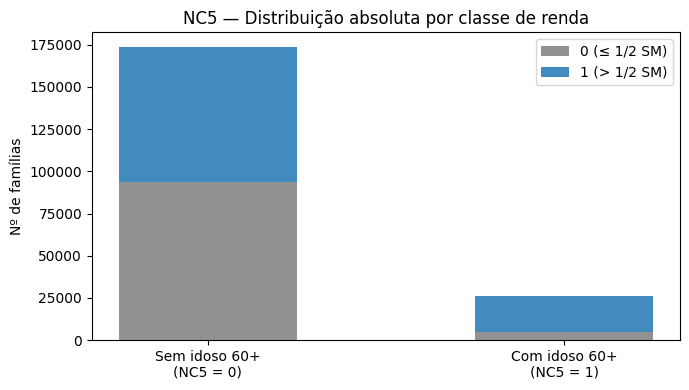

,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
Sem idoso 60+\n(NC5 = 0),93878,79829,173707,46.0
Com idoso 60+\n(NC5 = 1),4796,21497,26293,81.8


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL       = "#1f77b4"
CINZA      = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"
VERD       = "#2ca02c"

col    = "NC5"    # Presença de idoso 60+ (binária: 0/1)
target = "y_bin"
CLASSES = [0, 1]

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# Tabela de contagem e proporção por valor (0 ou 1)
tab = (
    df_plot.groupby([col, target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)
prop  = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1).to_numpy()
labels = ["Sem idoso 60+\n(NC5 = 0)", "Com idoso 60+\n(NC5 = 1)"]

# -----------------------------
# PLOT 1 — Proporção por classe
# -----------------------------
fig, ax1 = plt.subplots(figsize=(7, 4))

x = np.array([0, 1])
width = 0.35

b0 = ax1.bar(x - width/2, prop[0].to_numpy(), width, color=CINZA,  label="0 (≤ 1/2 SM)", alpha=0.85)
b1 = ax1.bar(x + width/2, prop[1].to_numpy(), width, color=AZUL,   label="1 (> 1/2 SM)", alpha=0.85)

# Anotações de percentual
for bars in [b0, b1]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.1%}", ha="center", va="bottom", fontsize=9)

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Proporção por classe")
ax1.set_title("NC5 — Presença de idoso 60+ vs classe de renda (y_bin)")
ax1.legend()
ax1.grid(False)

ax2 = ax1.twinx()
ax2.set_ylabel("Contagem de famílias")

plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2 — Contagem absoluta empilhada
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x, tab[0].to_numpy(), width=0.5, color=CINZA, label="0 (≤ 1/2 SM)", alpha=0.85)
ax.bar(x, tab[1].to_numpy(), width=0.5, color=AZUL,  label="1 (> 1/2 SM)",
       alpha=0.85, bottom=tab[0].to_numpy())

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Nº de famílias")
ax.set_title("NC5 — Distribuição absoluta por classe de renda")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# TABELA RESUMO
# -----------------------------
df_resumo = tab.copy()
df_resumo.index = labels
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"] = counts
df_resumo["% Classe 1"] = (tab[1] / counts * 100).round(1).values
display(df_resumo)



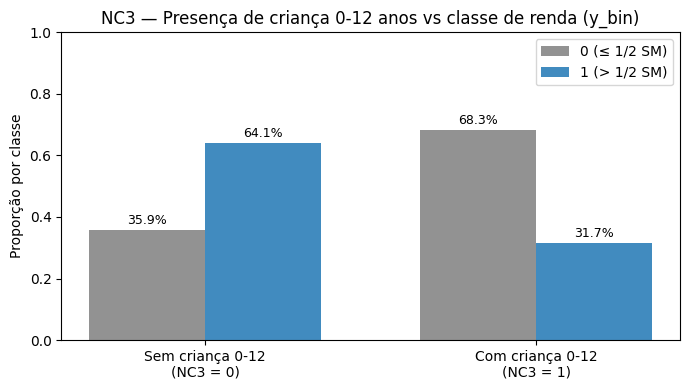

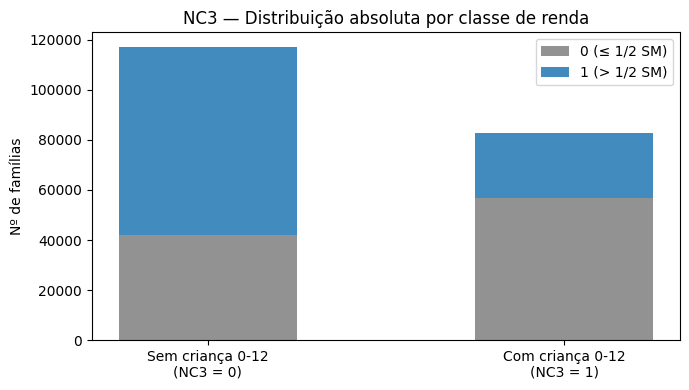

,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
Sem criança 0-12\n(NC3 = 0),42060,75101,117161,64.1
Com criança 0-12\n(NC3 = 1),56614,26225,82839,31.7


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col    = "NC3"    # Presença de criança 0 a 12 anos (binária: 0/1)
target = "y_bin"
CLASSES = [0, 1]

mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
labels = ["Sem criança 0-12\n(NC3 = 0)", "Com criança 0-12\n(NC3 = 1)"]

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# -----------------------------
# TABELA
# -----------------------------
tab = (
    df_plot.groupby([col, target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT 1 — Proporção por classe
# -----------------------------
x     = np.array([0, 1])
width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 4))

b0 = ax1.bar(x - width/2, prop[0].to_numpy(), width, color=CINZA, label=mapa_y[0], alpha=0.85)
b1 = ax1.bar(x + width/2, prop[1].to_numpy(), width, color=AZUL,  label=mapa_y[1], alpha=0.85)

for bars in [b0, b1]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.1%}", ha="center", va="bottom", fontsize=9)

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Proporção por classe")
ax1.set_title("NC3 — Presença de criança 0-12 anos vs classe de renda (y_bin)")
ax1.legend()
ax1.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2 — Contagem absoluta empilhada
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x, tab[0].to_numpy(), width=0.5, color=CINZA, label=mapa_y[0], alpha=0.85)
ax.bar(x, tab[1].to_numpy(), width=0.5, color=AZUL,  label=mapa_y[1],
       alpha=0.85, bottom=tab[0].to_numpy())

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Nº de famílias")
ax.set_title("NC3 — Distribuição absoluta por classe de renda")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# TABELA RESUMO
# -----------------------------
df_resumo = tab.copy()
df_resumo.index = labels
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"] = counts
df_resumo["% Classe 1"] = (tab[1] / counts * 100).round(1).values
display(df_resumo)



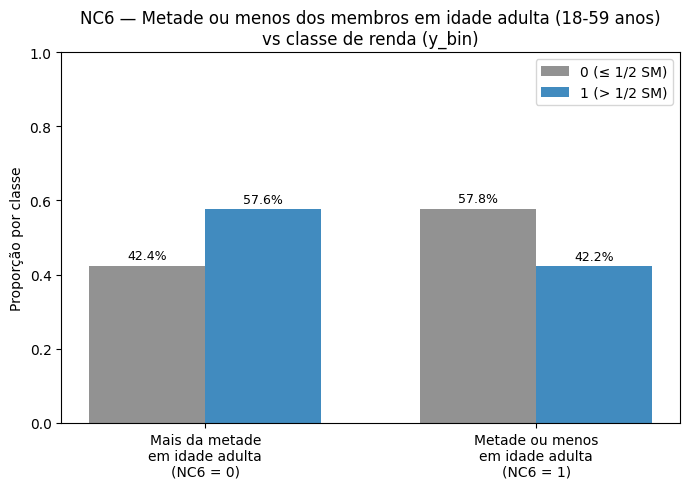

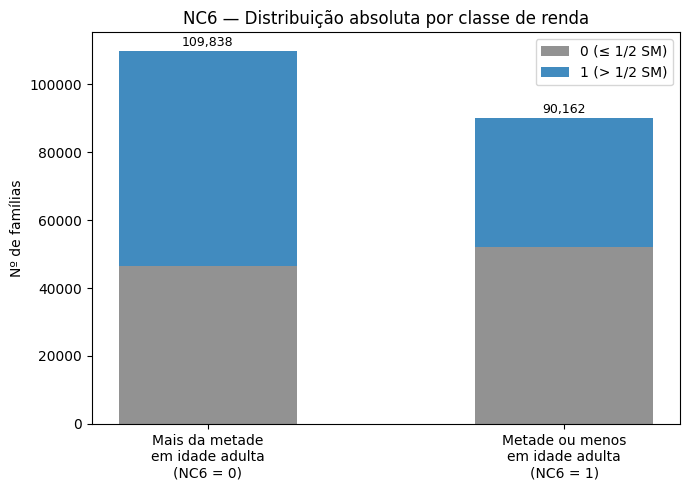

,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
Mais da metade\nem idade adulta\n(NC6 = 0),46571,63267,109838,57.6
Metade ou menos\nem idade adulta\n(NC6 = 1),52103,38059,90162,42.2


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col    = "NC6"    # Metade ou menos dos membros em idade adulta (18-59 anos)
target = "y_bin"
CLASSES = [0, 1]

mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
labels = [
    "Mais da metade\nem idade adulta\n(NC6 = 0)",
    "Metade ou menos\nem idade adulta\n(NC6 = 1)"
]

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# -----------------------------
# TABELA
# -----------------------------
tab = (
    df_plot.groupby([col, target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT 1 — Proporção por classe
# -----------------------------
x     = np.array([0, 1])
width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 5))

b0 = ax1.bar(x - width/2, prop[0].to_numpy(), width, color=CINZA, label=mapa_y[0], alpha=0.85)
b1 = ax1.bar(x + width/2, prop[1].to_numpy(), width, color=AZUL,  label=mapa_y[1], alpha=0.85)

for bars in [b0, b1]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.1%}", ha="center", va="bottom", fontsize=9)

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Proporção por classe")
ax1.set_title("NC6 — Metade ou menos dos membros em idade adulta (18-59 anos)\nvs classe de renda (y_bin)")
ax1.legend()
ax1.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2 — Contagem absoluta empilhada
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x, tab[0].to_numpy(), width=0.5, color=CINZA, label=mapa_y[0], alpha=0.85)
ax.bar(x, tab[1].to_numpy(), width=0.5, color=AZUL,  label=mapa_y[1],
       alpha=0.85, bottom=tab[0].to_numpy())

for i, (c0, c1, tot) in enumerate(zip(tab[0], tab[1], counts)):
    ax.text(i, tot + 500, f"{tot:,}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Nº de famílias")
ax.set_title("NC6 — Distribuição absoluta por classe de renda")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# TABELA RESUMO
# -----------------------------
df_resumo = tab.copy()
df_resumo.index = labels
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"]      = counts
df_resumo["% Classe 1"] = (tab[1] / counts * 100).round(1).values
display(df_resumo)

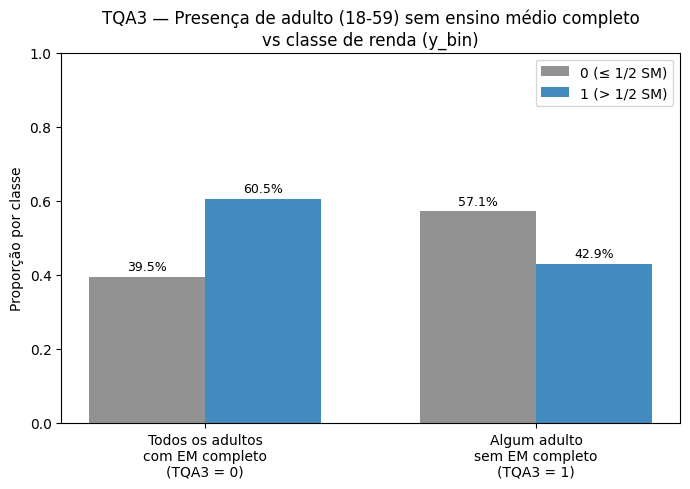

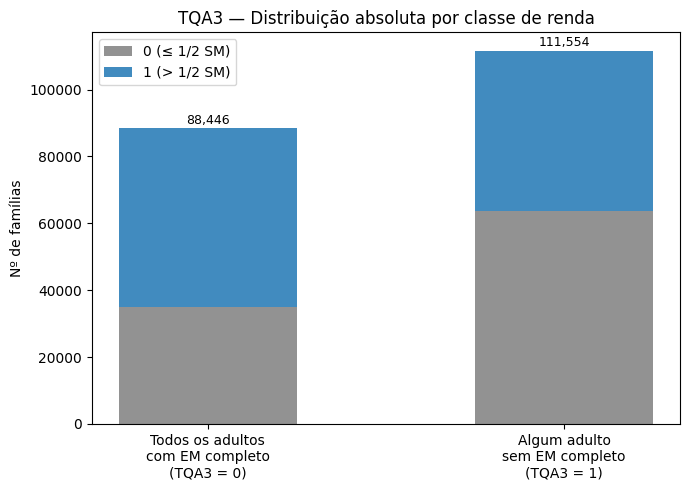

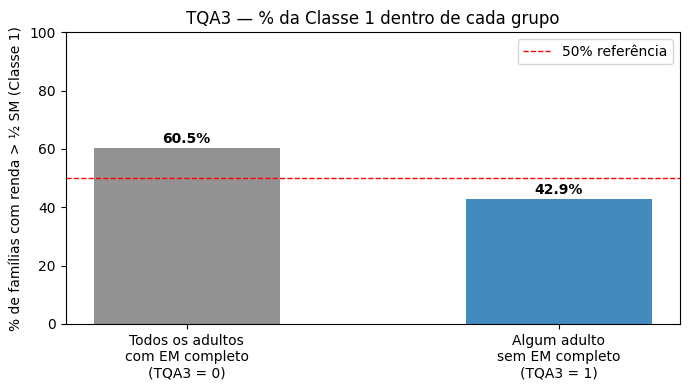

,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
Todos os adultos\ncom EM completo\n(TQA3 = 0),34967,53479,88446,60.5
Algum adulto\nsem EM completo\n(TQA3 = 1),63707,47847,111554,42.9


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"

col    = "TQA3"   # Presença de adulto sem ensino médio completo (18-59 anos)
target = "y_bin"
CLASSES = [0, 1]

mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
labels = [
    "Todos os adultos\ncom EM completo\n(TQA3 = 0)",
    "Algum adulto\nsem EM completo\n(TQA3 = 1)"
]

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# -----------------------------
# TABELA
# -----------------------------
tab = (
    df_plot.groupby([col, target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT 1 — Proporção por classe
# -----------------------------
x     = np.array([0, 1])
width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 5))

b0 = ax1.bar(x - width/2, prop[0].to_numpy(), width, color=CINZA, label=mapa_y[0], alpha=0.85)
b1 = ax1.bar(x + width/2, prop[1].to_numpy(), width, color=AZUL,  label=mapa_y[1], alpha=0.85)

for bars in [b0, b1]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.1%}", ha="center", va="bottom", fontsize=9)

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Proporção por classe")
ax1.set_title("TQA3 — Presença de adulto (18-59) sem ensino médio completo\nvs classe de renda (y_bin)")
ax1.legend()
ax1.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2 — Contagem absoluta empilhada
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x, tab[0].to_numpy(), width=0.5, color=CINZA, label=mapa_y[0], alpha=0.85)
ax.bar(x, tab[1].to_numpy(), width=0.5, color=AZUL,  label=mapa_y[1],
       alpha=0.85, bottom=tab[0].to_numpy())

for i, tot in enumerate(counts):
    ax.text(i, tot + 500, f"{tot:,}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Nº de famílias")
ax.set_title("TQA3 — Distribuição absoluta por classe de renda")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 3 — Proporção de classe 1 dentro de cada grupo (destaca o contraste)
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

pct_classe1 = (tab[1] / counts * 100)
bars = ax.bar(x, pct_classe1.to_numpy(), width=0.5, color=[CINZA, AZUL], alpha=0.85)

for bar, val in zip(bars, pct_classe1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% de famílias com renda > ½ SM (Classe 1)")
ax.set_title("TQA3 — % da Classe 1 dentro de cada grupo")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="50% referência")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# TABELA RESUMO
# -----------------------------
df_resumo = tab.copy()
df_resumo.index = labels
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"]      = counts
df_resumo["% Classe 1"] = (tab[1] / counts * 100).round(1).values
display(df_resumo)

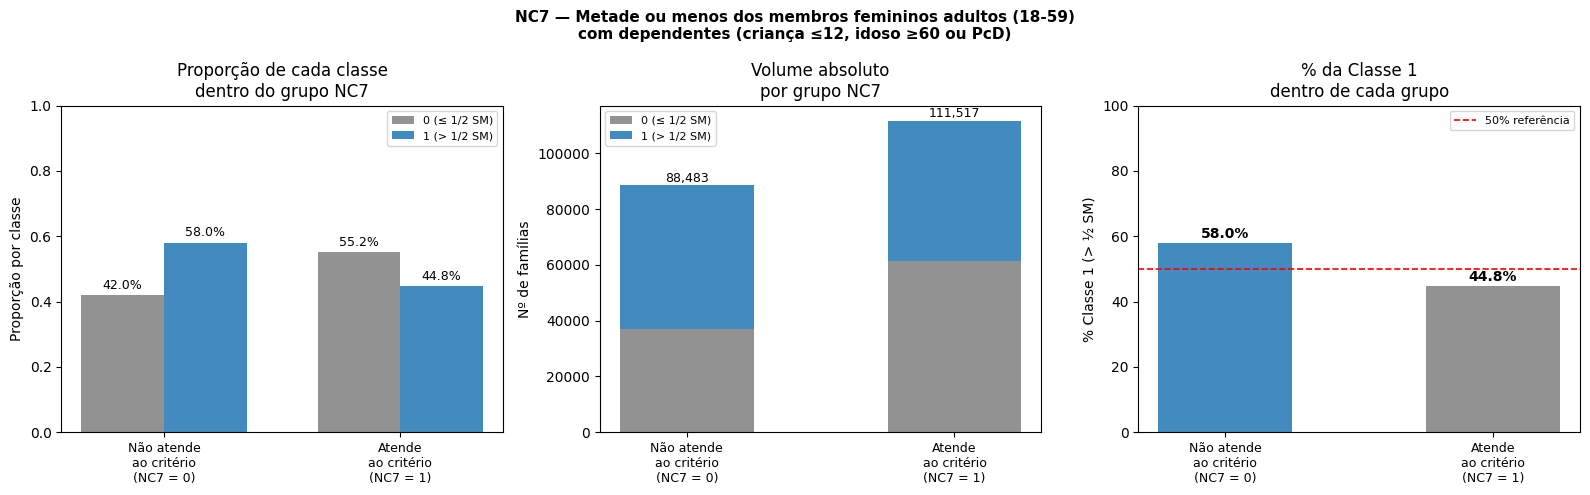

=== Sobreposição NC7 com outros indicadores de dependência ===
NC3    71.8
NC4    21.1
NC5    22.6



,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
Não atende\nao critério\n(NC7 = 0),37160,51323,88483,58.0
Atende\nao critério\n(NC7 = 1),61514,50003,111517,44.8


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"
LARANJA     = "#ff7f0e"
VERDE       = "#2ca02c"

col    = "NC7"
target = "y_bin"
CLASSES = [0, 1]

mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
labels = [
    "Não atende\nao critério\n(NC7 = 0)",
    "Atende\nao critério\n(NC7 = 1)"
]

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# -----------------------------
# TABELA
# -----------------------------
tab = (
    df_plot.groupby([col, target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1).to_numpy()
pct_c1 = (tab[1] / counts * 100).round(1).values

# -----------------------------
# FIGURA COMPLETA (3 subplots)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "NC7 — Metade ou menos dos membros femininos adultos (18-59)\n"
    "com dependentes (criança ≤12, idoso ≥60 ou PcD)",
    fontsize=11, fontweight="bold"
)

x     = np.array([0, 1])
width = 0.35

# ── Subplot 1: Proporção por classe ──────────────────────────
ax1 = axes[0]
b0 = ax1.bar(x - width/2, prop[0].to_numpy(), width, color=CINZA,   label=mapa_y[0], alpha=0.85)
b1 = ax1.bar(x + width/2, prop[1].to_numpy(), width, color=AZUL,    label=mapa_y[1], alpha=0.85)

for bars in [b0, b1]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.1%}", ha="center", va="bottom", fontsize=9)

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("Proporção por classe")
ax1.set_title("Proporção de cada classe\ndentro do grupo NC7")
ax1.legend(fontsize=8)
ax1.grid(False)

# ── Subplot 2: Contagem absoluta empilhada ───────────────────
ax2 = axes[1]
ax2.bar(x, tab[0].to_numpy(), width=0.5, color=CINZA, label=mapa_y[0], alpha=0.85)
ax2.bar(x, tab[1].to_numpy(), width=0.5, color=AZUL,  label=mapa_y[1],
        alpha=0.85, bottom=tab[0].to_numpy())

for i, tot in enumerate(counts):
    ax2.text(i, tot + 300, f"{tot:,}", ha="center", va="bottom", fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Nº de famílias")
ax2.set_title("Volume absoluto\npor grupo NC7")
ax2.legend(fontsize=8)
ax2.grid(False)

# ── Subplot 3: % Classe 1 dentro de cada grupo ───────────────
ax3 = axes[2]
cores = [CINZA if v < 50 else AZUL for v in pct_c1]
bars  = ax3.bar(x, pct_c1, width=0.5, color=cores, alpha=0.85)

for bar, val in zip(bars, pct_c1):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax3.axhline(50, color="red", linestyle="--", linewidth=1.2, label="50% referência")
ax3.set_ylim(0, 100)
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=9)
ax3.set_ylabel("% Classe 1 (> ½ SM)")
ax3.set_title("% da Classe 1\ndentro de cada grupo")
ax3.legend(fontsize=8)
ax3.grid(False)

plt.tight_layout()
plt.savefig("nc7_analise.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------
# TABELA RESUMO
# -----------------------------
df_resumo = tab.copy()
df_resumo.index = labels
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"]      = counts
df_resumo["% Classe 1"] = pct_c1

# Contexto adicional: NC7 depende de NC4, NC5 ou NC3 simultaneamente
# Verifica sobreposição com NC3, NC4, NC5 no X_test
print("=== Sobreposição NC7 com outros indicadores de dependência ===")
df_overlap = X_test[["NC3", "NC4", "NC5", "NC7"]].copy()
df_overlap[target] = y_test.values

overlap = (
    df_overlap[df_overlap["NC7"] == 1]
    .agg({"NC3": "mean", "NC4": "mean", "NC5": "mean"})
    .rename("% com NC7=1 que também tem")
    * 100
).round(1)

print(overlap.to_string())
print()
display(df_resumo)

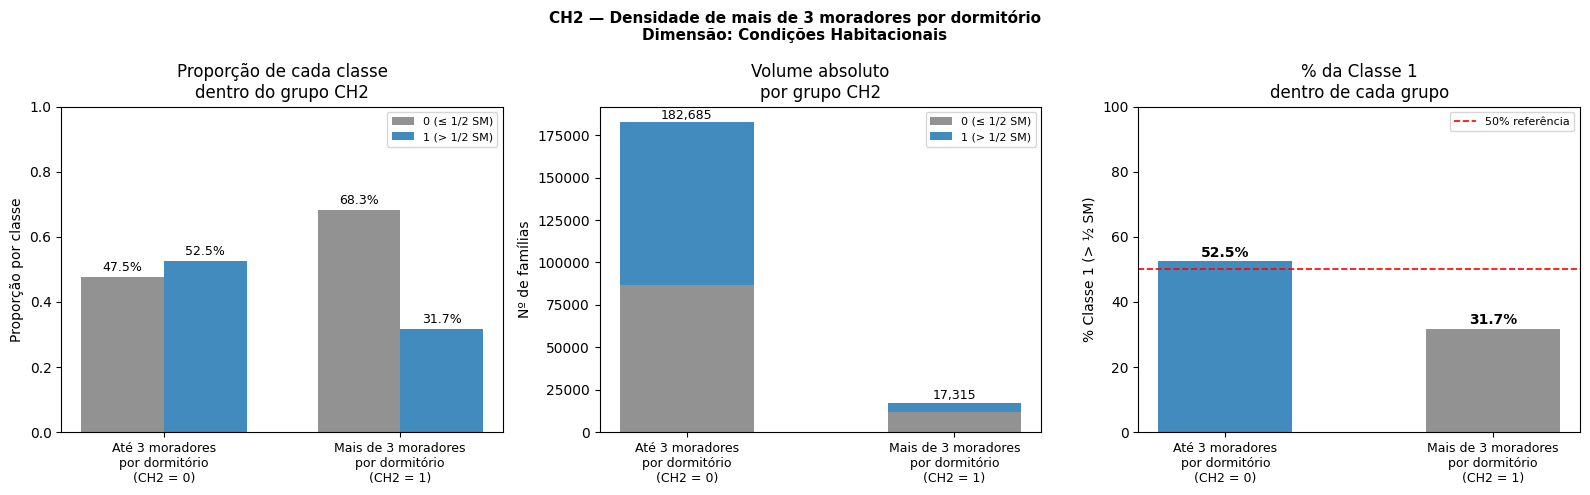

,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
Até 3 moradores\npor dormitório\n(CH2 = 0),86856,95829,182685,52.5
Mais de 3 moradores\npor dormitório\n(CH2 = 1),11818,5497,17315,31.7


=== Sobreposição CH2 com outras variáveis habitacionais ===
CH5     41.5
CH6     44.3
CH7     52.3
CH9     42.5
CH10    57.2
CH11    52.6

QT_PESSOAS_DOMIC_FAM / QT_COMODOS_DORMITORIO_FAM não disponíveis em X_test.


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"
LARANJA     = "#ff7f0e"

col    = "CH2"
target = "y_bin"
CLASSES = [0, 1]

mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
labels = [
    "Até 3 moradores\npor dormitório\n(CH2 = 0)",
    "Mais de 3 moradores\npor dormitório\n(CH2 = 1)"
]

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# -----------------------------
# TABELA
# -----------------------------
tab = (
    df_plot.groupby([col, target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1).to_numpy()
pct_c1 = (tab[1] / counts * 100).round(1).values

# -----------------------------
# FIGURA COMPLETA (3 subplots)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "CH2 — Densidade de mais de 3 moradores por dormitório\n"
    "Dimensão: Condições Habitacionais",
    fontsize=11, fontweight="bold"
)

x     = np.array([0, 1])
width = 0.35

# ── Subplot 1: Proporção por classe ──────────────────────────
ax1 = axes[0]
b0 = ax1.bar(x - width/2, prop[0].to_numpy(), width, color=CINZA, label=mapa_y[0], alpha=0.85)
b1 = ax1.bar(x + width/2, prop[1].to_numpy(), width, color=AZUL,  label=mapa_y[1], alpha=0.85)

for bars in [b0, b1]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.1%}", ha="center", va="bottom", fontsize=9)

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("Proporção por classe")
ax1.set_title("Proporção de cada classe\ndentro do grupo CH2")
ax1.legend(fontsize=8)
ax1.grid(False)

# ── Subplot 2: Contagem absoluta empilhada ───────────────────
ax2 = axes[1]
ax2.bar(x, tab[0].to_numpy(), width=0.5, color=CINZA, label=mapa_y[0], alpha=0.85)
ax2.bar(x, tab[1].to_numpy(), width=0.5, color=AZUL,  label=mapa_y[1],
        alpha=0.85, bottom=tab[0].to_numpy())

for i, tot in enumerate(counts):
    ax2.text(i, tot + 300, f"{tot:,}", ha="center", va="bottom", fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Nº de famílias")
ax2.set_title("Volume absoluto\npor grupo CH2")
ax2.legend(fontsize=8)
ax2.grid(False)

# ── Subplot 3: % Classe 1 dentro de cada grupo ───────────────
ax3 = axes[2]
cores = [CINZA if v < 50 else AZUL for v in pct_c1]
bars  = ax3.bar(x, pct_c1, width=0.5, color=cores, alpha=0.85)

for bar, val in zip(bars, pct_c1):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax3.axhline(50, color="red", linestyle="--", linewidth=1.2, label="50% referência")
ax3.set_ylim(0, 100)
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=9)
ax3.set_ylabel("% Classe 1 (> ½ SM)")
ax3.set_title("% da Classe 1\ndentro de cada grupo")
ax3.legend(fontsize=8)
ax3.grid(False)

plt.tight_layout()
plt.savefig("ch2_analise.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------
# TABELA RESUMO
# -----------------------------
df_resumo = tab.copy()
df_resumo.index = labels
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"]      = counts
df_resumo["% Classe 1"] = pct_c1
display(df_resumo)

# -----------------------------
# CONTEXTO: sobreposição CH2 com outras condições habitacionais
# -----------------------------
print("=== Sobreposição CH2 com outras variáveis habitacionais ===")
ch_cols = ["CH1", "CH5", "CH6", "CH7", "CH9", "CH10", "CH11"]
ch_cols_eff = [c for c in ch_cols if c in X_test.columns]

df_overlap = X_test[ch_cols_eff + ["CH2"]].copy()
overlap = (
    df_overlap[df_overlap["CH2"] == 1]
    .agg({c: "mean" for c in ch_cols_eff})
    .rename("% com CH2=1 que também tem")
    * 100
).round(1)

print(overlap.to_string())

# -----------------------------
# CONTEXTO: relação CH2 com número de pessoas e dormitórios
# (se VL_RENDA_MEDIA_FAM estiver disponível no X_test)
# -----------------------------
cols_hab = [c for c in ["QT_PESSOAS_DOMIC_FAM", "QT_COMODOS_DORMITORIO_FAM"] if c in X_test.columns]
if cols_hab:
    print("\n=== Média de pessoas e dormitórios por grupo CH2 ===")
    df_hab = X_test[cols_hab + ["CH2"]].copy()
    print(df_hab.groupby("CH2")[cols_hab].mean().round(2).to_string())
else:
    print("\nQT_PESSOAS_DOMIC_FAM / QT_COMODOS_DORMITORIO_FAM não disponíveis em X_test.")

## Análises adicionais considerando as classes de renda originais

In [52]:
THR = 0.80
df_test = df.loc[X_test.index, ["classe_renda"]].copy()
df_test["y_bin"] = y_test
df_test["proba_pos"] = pipe_final.predict_proba(X_test)[:, 1]
df_test["y_pred_thr"] = (df_test["proba_pos"] >= THR).astype(int)
# flags de avaliação
df_test["TP"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==1)
df_test["FP"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==1)
df_test["FN"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==0)
df_test["TN"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==0)
df_test.head()



,classe_renda,y_bin,proba_pos,y_pred_thr,TP,FP,FN,TN
599390,2,1,0.931077,1,True,False,False,False
61733,1,0,0.632877,0,False,False,False,True
90819,1,0,0.219211,0,False,False,False,True
211607,0,0,0.265362,0,False,False,False,True
745268,1,0,0.787392,0,False,False,False,True


In [53]:
assert len(df_test) == len(X_test) == len(y_test)
df_test["classe_renda"].value_counts()


classe_renda
2    101326
1     66923
0     31751
Name: count, dtype: int64

### Distribuição de classe_renda por predição (convocados vs não)

In [54]:
tab = pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"], normalize="columns")
tab.columns = ["Não convocado (pred=0)", "Convocado (pred=1)"]
tab

,Não convocado (pred=0),Convocado (pred=1)
classe_renda,,
0,0.177837,0.026016
1,0.367747,0.104145
2,0.454415,0.869838


In [55]:
pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"])

y_pred_thr,0,1
classe_renda,,
0,31097,654
1,64305,2618
2,79460,21866


### Perfil do risco (proba) dentro de cada classe_renda

In [56]:
df_test.groupby("classe_renda")["proba_pos"].agg(
    media="mean",
    p25=lambda s: s.quantile(0.25),
    mediana="median",
    p75=lambda s: s.quantile(0.75),
    p90=lambda s: s.quantile(0.90),
    n="size"
)

,media,p25,mediana,p75,p90,n
classe_renda,,,,,,
0,0.296374,0.091016,0.248816,0.472717,0.647437,31751
1,0.423376,0.242522,0.426767,0.597605,0.717316,66923
2,0.628172,0.497376,0.658338,0.783957,0.869853,101326


### Avaliação no subconjunto classe_renda == 0 (pobreza)

In [57]:
sub = df_test[df_test["classe_renda"] == 0]

res = {
    "thr": THR,
    "n": len(sub),
    "taxa_convocacao": sub["y_pred_thr"].mean(),
    "precision_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FP"].sum()) if (sub["TP"].sum() + sub["FP"].sum())>0 else np.nan,
    "recall_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FN"].sum()) if (sub["TP"].sum() + sub["FN"].sum())>0 else np.nan,
    "TP": int(sub["TP"].sum()),
    "FP": int(sub["FP"].sum()),
    "FN": int(sub["FN"].sum()),
    "TN": int(sub["TN"].sum()),
}
pd.Series(res)

thr                    0.800000
n                  31751.000000
taxa_convocacao        0.020598
precision_pos          0.000000
recall_pos                  NaN
TP                     0.000000
FP                   654.000000
FN                     0.000000
TN                 31097.000000
dtype: float64

### Perfil de classe_renda dentro dos Falsos Positivos (FP)

In [58]:
fp = df_test[df_test["FP"]]
fp["classe_renda"].value_counts(normalize=True).sort_index()


classe_renda
0    0.199878
1    0.800122
Name: proportion, dtype: float64

In [59]:
fp["classe_renda"].value_counts().sort_index()

classe_renda
0     654
1    2618
Name: count, dtype: int64

### Perfil dos Falsos Negativos (FN) dentro de classe_renda == 2

In [60]:
fn2 = df_test[(df_test["FN"]) & (df_test["classe_renda"] == 2)]
fn2.shape, fn2["proba_pos"].describe()

((79460, 8),
 count    79460.000000
 mean         0.561761
 std          0.171091
 min          0.003752
 25%          0.458325
 50%          0.601681
 75%          0.700697
 max          0.799989
 Name: proba_pos, dtype: float64)

In [61]:
tp2 = df_test[(df_test["TP"]) & (df_test["classe_renda"] == 2)]
pd.DataFrame({
    "FN_cl2_proba": fn2["proba_pos"].describe(),
    "TP_cl2_proba": tp2["proba_pos"].describe()
})

,FN_cl2_proba,TP_cl2_proba
count,79460.000000,21866.000000
mean,0.561761,0.869504
std,0.171091,0.036856
min,0.003752,0.800002
25%,0.458325,0.842834
50%,0.601681,0.867322
75%,0.700697,0.897533
max,0.799989,0.971552


### Sensibilidade ao threshold por classe_renda (0.75/0.80/0.85)

In [62]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    tmp = df_test.copy()
    tmp["pred"] = pred

    out = tmp.groupby("classe_renda")["pred"].mean().rename("taxa_convocacao").reset_index()
    out["threshold"] = t
    rows.append(out)

pd.concat(rows, ignore_index=True).pivot(index="classe_renda", columns="threshold", values="taxa_convocacao")

threshold,0.75,0.80,0.85
classe_renda,,,
0,0.034834,0.020598,0.011622
1,0.067914,0.039120,0.022354
2,0.299657,0.215799,0.148234


### “Precisão esperada” por threshold no grupo pobreza (classe 0)

In [63]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    sub = df_test[df_test["classe_renda"] == 0].copy()
    TP = ((sub["y_bin"]==1) & (pred[sub.index]==1)).sum()
    FP = ((sub["y_bin"]==0) & (pred[sub.index]==1)).sum()

    prec = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    conv = (pred[sub.index]==1).mean()

    rows.append({"threshold": t, "precision_pos_pobreza": prec, "taxa_convocacao_pobreza": conv})

pd.DataFrame(rows)


,threshold,precision_pos_pobreza,taxa_convocacao_pobreza
0,0.75,0.0,0.034834
1,0.80,0.0,0.020598
2,0.85,0.0,0.011622


### Criar grupos operacionais (classe_renda × convocação × risco)

In [64]:
df_test["faixa_risco"] = pd.cut(
    df_test["proba_pos"],
    bins=[-np.inf, 0.50, THR, np.inf],
    labels=["Baixo (<0.50)", f"Médio (0.50–{THR:.2f})", f"Alto (≥{THR:.2f})"]
)

tipologia = pd.crosstab(
    [df_test["classe_renda"], df_test["faixa_risco"]],
    df_test["y_pred_thr"],
    normalize="index"
)

tipologia.columns = ["Não convocado", "Convocado"]
tipologia

Não convocado  Convocado
classe_renda faixa_risco                                
0            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
1            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
2            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0

In [65]:
pd.crosstab([df_test["classe_renda"], df_test["faixa_risco"]], df_test["y_pred_thr"])

y_pred_thr                          0      1
classe_renda faixa_risco                    
0            Baixo (<0.50)      24955      0
             Médio (0.50–0.80)   6142      0
             Alto (≥0.80)           0    654
1            Baixo (<0.50)      41579      0
             Médio (0.50–0.80)  22726      0
             Alto (≥0.80)           0   2618
2            Baixo (<0.50)      25847      0
             Médio (0.50–0.80)  53613      0
             Alto (≥0.80)           0  21866

## Salvando o modelo final

In [68]:
import os
from pathlib import Path

# importa a classe para o pickle conseguir reconstruir o objeto
from models.xgb_threshold import XGBoostComThreshold

import joblib

PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'QTD_PESSOAS',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11'...
                                                   'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'IN_FREQUENTA_ESCOLA_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', XGBoostComThreshold())])

In [69]:
from pathlib import Path

# garante que a classe custom existe como módulo importável (essencial p/ joblib depois)
from models.xgb_threshold import XGBoostComThreshold

# pasta padrão do projeto
DIR_MODELS = Path("models")
DIR_MODELS.mkdir(exist_ok=True)

# nome padronizado do arquivo do pipeline
MODEL_NAME = "pipeline_xgb_binario_thr080"
PATH_MODEL = DIR_MODELS / f"{MODEL_NAME}.joblib"

print("Modelo será salvo em:", PATH_MODEL)


Modelo será salvo em: models\pipeline_xgb_binario_thr080.joblib


In [70]:
import os
from pathlib import Path
import joblib
import pandas as pd


# importante: importar a classe custom antes do load
from models.xgb_threshold import XGBoostComThreshold

# carregar modelo já treinado
PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

# carregar base de aplicação
PATH_APLIC = Path("fam_pes_cad_11_25_amostra_aplicacao.csv")
df_app = pd.read_csv(PATH_APLIC)

# aplicar
proba = pipeline.predict_proba(df_app)[:, 1]
pred  = pipeline.predict(df_app)

df_out = df_app.copy()
df_out["PROB_RENDA_INFORMAL"] = proba
df_out["PRED_RENDA_INFORMAL"] = pred

df_out.to_csv("fam_pes_cad_11_25_resultado_ml.csv", index=False)
print("✅ Salvo:", "fam_pes_cad_11_25_resultado_ml.csv")


✅ Salvo: fam_pes_cad_11_25_resultado_ml.csv
